In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 设置中文字体为宋体或黑体
plt.rcParams["font.sans-serif"] = ["SimSong", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

[None]

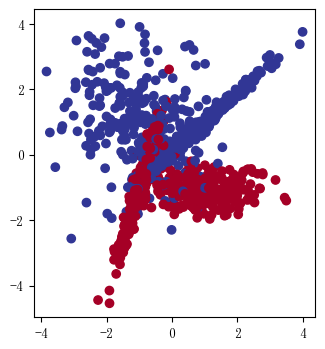

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_classes=2,
    random_state=42,
    n_clusters_per_class=2,
)

_, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
ax.set(aspect="equal")

In [3]:
features = pd.DataFrame(X, columns=["feature_1", "feature_2"])
target = pd.Series(y, name="target")
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)
print(f"训练集样本数: {len(y_train)}")
print(f"测试集样本数: {len(y_test)}")

训练集样本数: 700
测试集样本数: 300


## 决策树


### 不同分裂准则

gini准则准确率: 0.9033
entropy准则准确率: 0.9100
log_loss准则准确率: 0.9100


Text(0.5, 0.98, 'Decision Trees with Different Splitting Criteria')

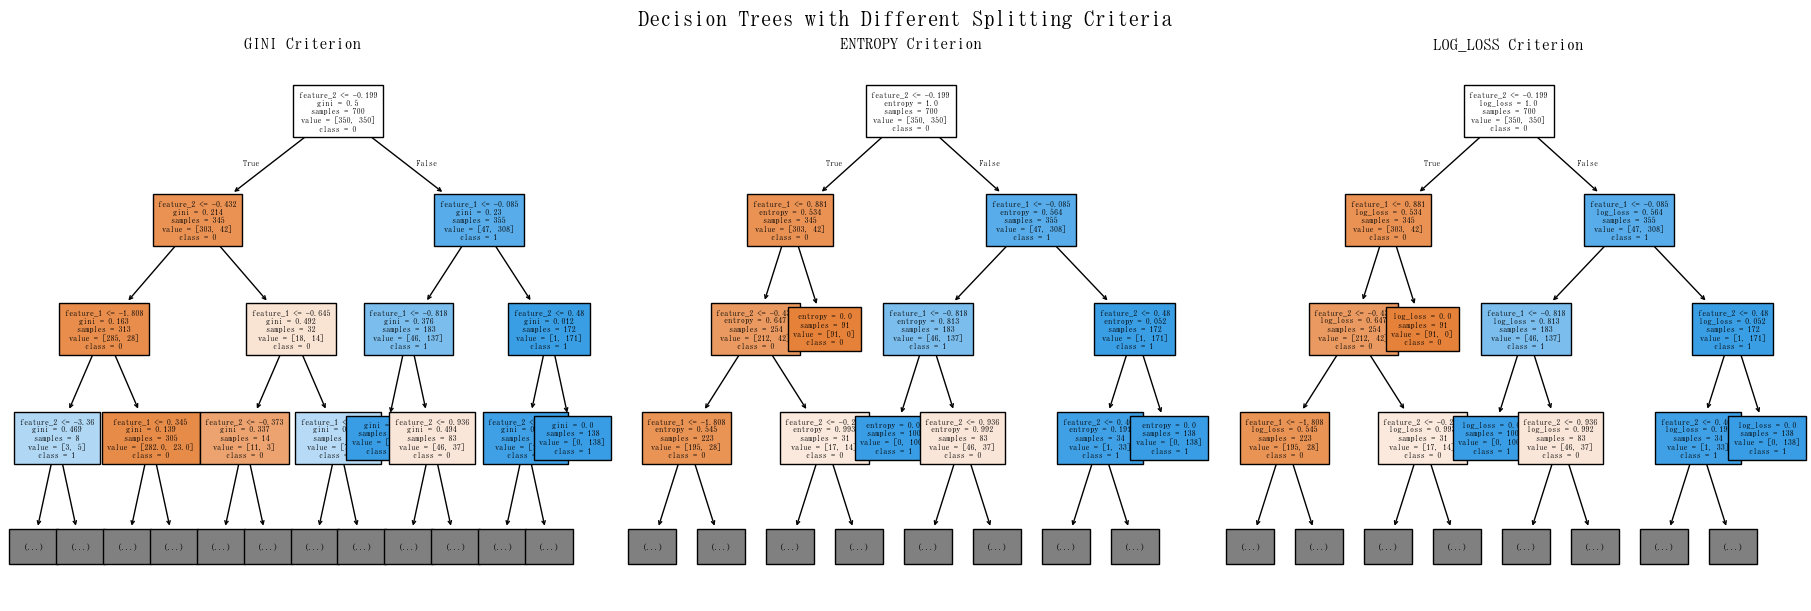

In [4]:
criteria = ["gini", "entropy", "log_loss"]

_, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=1)

for cr, ax in zip(criteria, axes):
    model_tree = DecisionTreeClassifier(criterion=cr, random_state=42)
    model_tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, model_tree.predict(X_test))
    print(f"{cr}准则准确率: {acc:.4f}")
    plot_tree(
        model_tree,
        max_depth=3,
        ax=ax,
        filled=True,
        feature_names=features.columns,
        class_names=["0", "1"],
        fontsize=6,
    )
    ax.set(title=f"{cr.upper()} Criterion")

plt.suptitle("Decision Trees with Different Splitting Criteria", fontsize=16)

### 不同预剪枝策略

Text(0.5, 0.98, 'Decision Trees with Different Pruning Strategies')

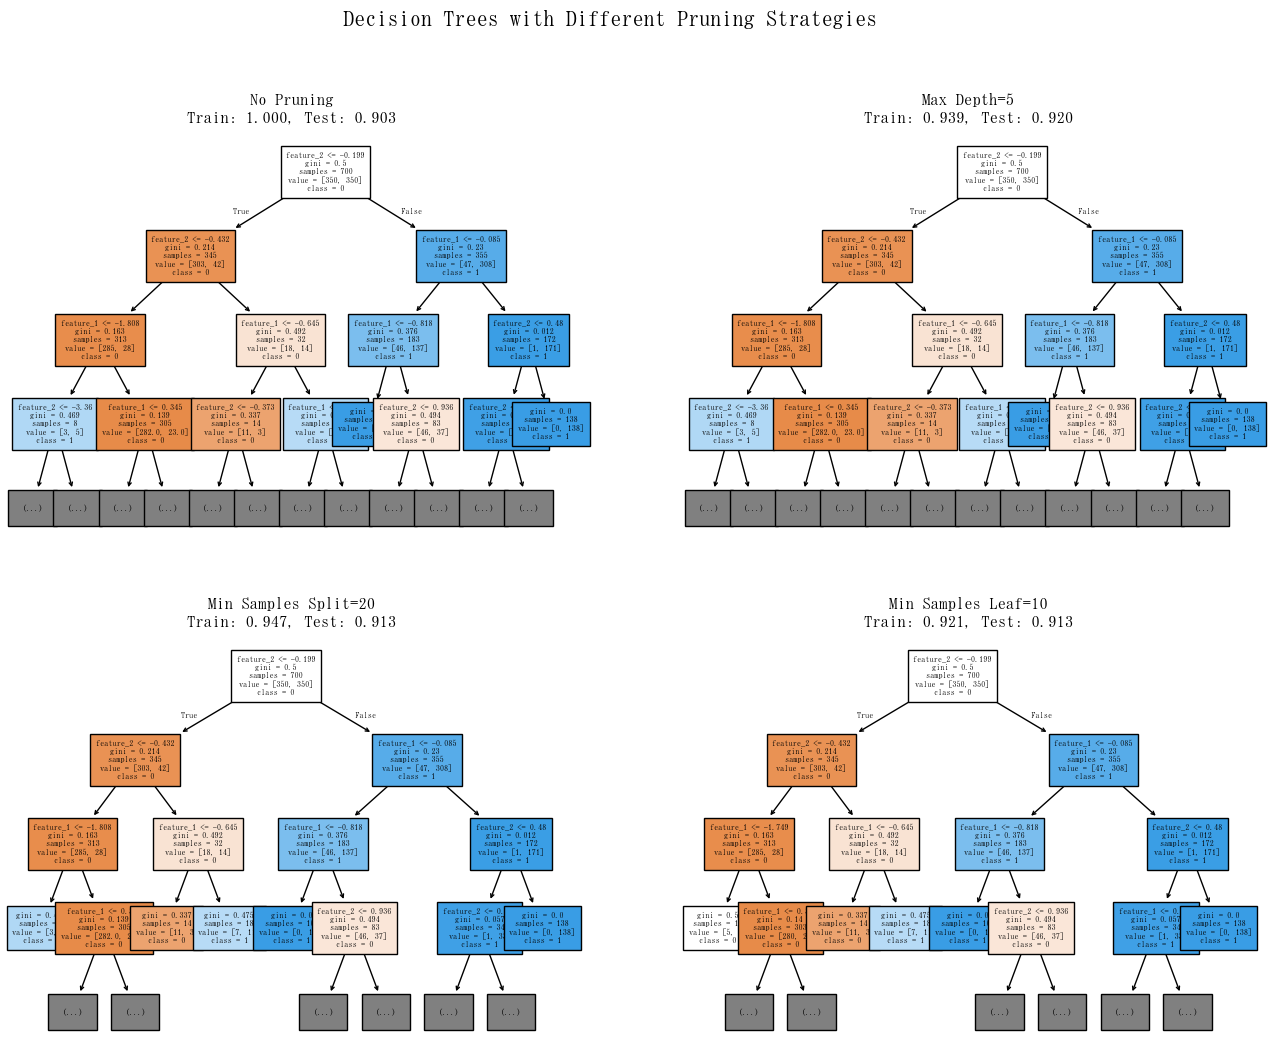

In [5]:
pruning_strategies = [
    ("No Pruning", {}),
    ("Max Depth=5", {"max_depth": 5}),
    ("Min Samples Split=20", {"min_samples_split": 20}),
    ("Min Samples Leaf=10", {"min_samples_leaf": 10}),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for (name, params), ax in zip(pruning_strategies, axes.flatten()):
    model = DecisionTreeClassifier(random_state=42, **params)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    plot_tree(
        model,
        max_depth=3,
        ax=ax,
        filled=True,
        feature_names=features.columns,
        class_names=["0", "1"],
        fontsize=6,
    )
    ax.set(title=f"{name}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}")
plt.suptitle("Decision Trees with Different Pruning Strategies", fontsize=16)


## 投票树

In [6]:
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=1)
estimators = [("lr", clf1), ("rf", clf2), ("dt", clf3)]

for name, clf in estimators:
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"{clf.__class__.__name__} 准确率: {acc:.4f}")


LogisticRegression 准确率: 0.8733
RandomForestClassifier 准确率: 0.9267
BaggingClassifier 准确率: 0.9233


### 硬投票vs软投票

Hard 投票准确率: 0.9267
Soft 投票准确率: 0.9400


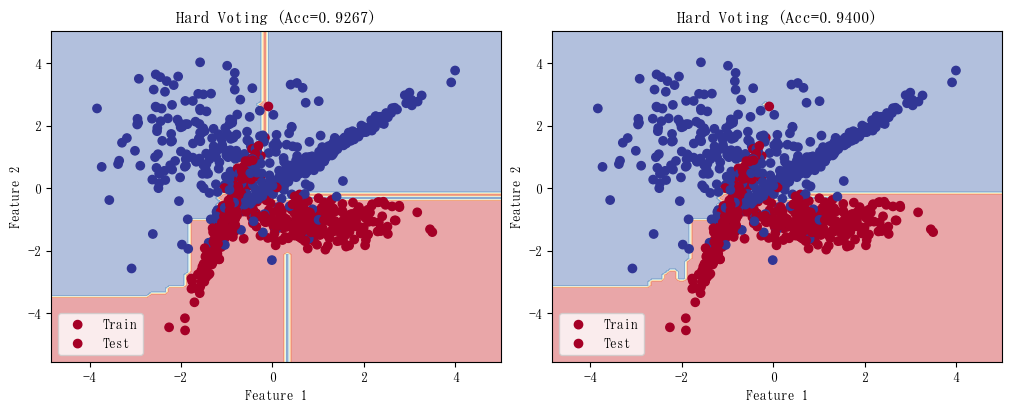

In [7]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=1)

for method, ax in zip(["hard", "soft"], axes.flatten()):
    model = VotingClassifier(estimators, voting=method)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{method.title()} 投票准确率: {acc:.4f}")
    DecisionBoundaryDisplay.from_estimator(
        model,
        features,
        ax=ax,
        alpha=0.4,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
    )
    ax.scatter(
        X_train.iloc[:, 0],
        X_train.iloc[:, 1],
        c=y_train,
        cmap=plt.cm.RdYlBu,
        label="Train",
    )
    ax.scatter(
        X_test.iloc[:, 0],
        X_test.iloc[:, 1],
        c=y_test,
        cmap=plt.cm.RdYlBu,
        label="Test",
    )
    ax.set(title=f"Hard Voting (Acc={acc:.4f})", xlabel="Feature 1", ylabel="Feature 2")
    ax.legend()


## 随机森林

### 使用全部特征Bagging和随机森林

[Text(0.5, 1.0, '随机森林数据集'), None]

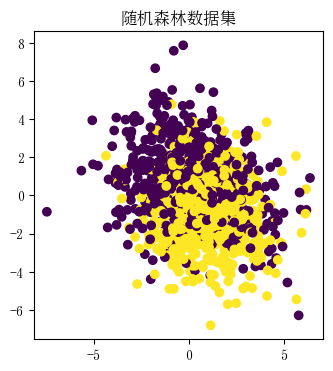

In [8]:
X_rf, y_rf = make_classification(
    n_samples=1000,
    n_features=10,
    n_redundant=0,
    n_informative=10,
    n_classes=2,
    random_state=42,
)

_, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_rf[:, 0], X_rf[:, 1], c=y_rf, cmap="viridis")
ax.set(title="随机森林数据集", aspect="equal")

In [9]:
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.3, random_state=42
)
model_full = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=50, max_features=1.0, random_state=42
)
model_rf = RandomForestClassifier(n_estimators=50, random_state=42)

for model in [model_full, model_rf]:
    model.fit(X_rf_train, y_rf_train)
    acc = accuracy_score(y_rf_test, model.predict(X_rf_test))
    print(f"{model.__class__.__name__} 准确率: {acc:.4f}")

BaggingClassifier 准确率: 0.8900
RandomForestClassifier 准确率: 0.8900


### 随机森林和极端随机树

In [10]:
model_rf = RandomForestClassifier(n_estimators=50, random_state=42)
model_et = ExtraTreesClassifier(n_estimators=50, random_state=42)
for model in [model_rf, model_et]:
    model.fit(X_rf_train, y_rf_train)
    acc = accuracy_score(y_rf_test, model.predict(X_rf_test))
    print(f"{model.__class__.__name__} 准确率: {acc:.4f}")

RandomForestClassifier 准确率: 0.8900
ExtraTreesClassifier 准确率: 0.9267


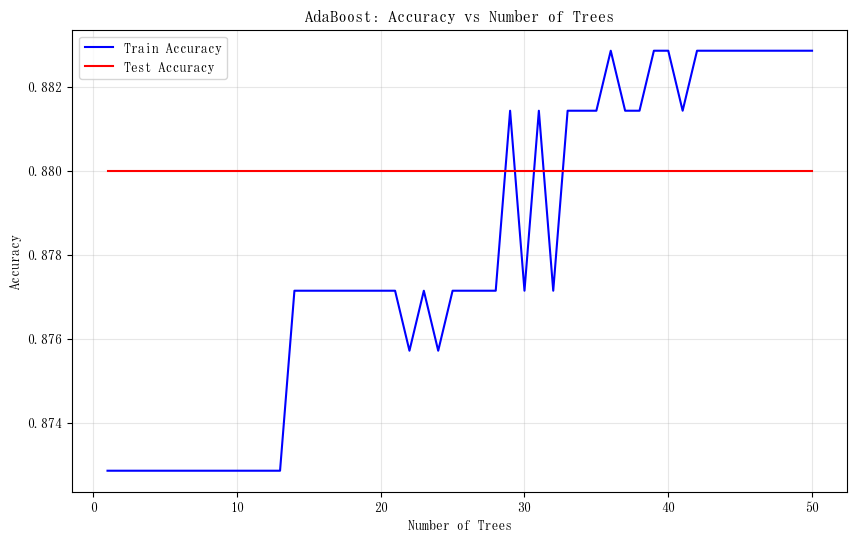

In [11]:
model_adaboost = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=42
)
model_adaboost.fit(X_train.values, y_train)
train_scores = [
    accuracy_score(y_train, pred)
    for pred in model_adaboost.staged_predict(X_train.values)
]
test_scores = [
    accuracy_score(y_test, pred)
    for pred in model_adaboost.staged_predict(X_test.values)
]
fig, ax = plt.subplots(figsize=(10, 6))
for score, color, label in zip(
    [train_scores, test_scores],
    ["blue", "red"],
    ["Train Accuracy", "Test Accuracy"],
):
    ax.plot(
        range(1, len(train_scores) + 1),
        score,
        color=color,
        label=label,
    )

ax.set(
    xlabel="Number of Trees",
    ylabel="Accuracy",
    title="AdaBoost: Accuracy vs Number of Trees",
)
ax.legend()
ax.grid(True, alpha=0.3)

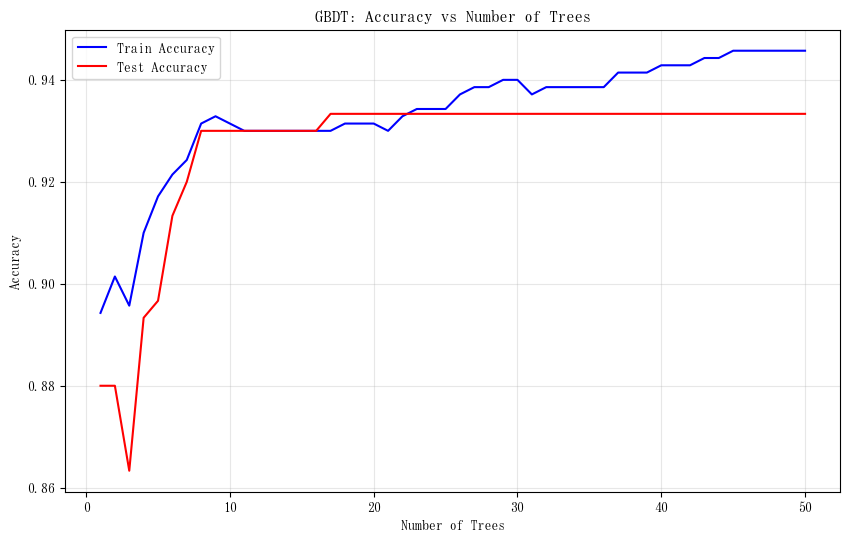

In [12]:
model_gbdt = GradientBoostingClassifier(n_estimators=50, random_state=42)
model_gbdt.fit(X_train, y_train)
train_scores = [
    accuracy_score(y_train, pred) for pred in model_gbdt.staged_predict(X_train)
]
test_scores = [
    accuracy_score(y_test, pred) for pred in model_gbdt.staged_predict(X_test)
]

fig, ax = plt.subplots(figsize=(10, 6))
for score, color, label in zip(
    [train_scores, test_scores],
    ["blue", "red"],
    ["Train Accuracy", "Test Accuracy"],
):
    ax.plot(
        range(1, len(train_scores) + 1),
        score,
        color=color,
        label=label,
    )
ax.set(
    xlabel="Number of Trees",
    ylabel="Accuracy",
    title="GBDT: Accuracy vs Number of Trees",
)
ax.legend()
ax.grid(True, alpha=0.3)